In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA_PATH = "../data/panel_june_ready.csv"

YEARS       = [1990, 1995, 2000, 2005, 2010, 2015]
YEARS_TRAIN = [y for y in YEARS if y <= 2010]

PAYS_EXCLUS = {'SSD', 'MNE', 'TLS', 'CUW', 'GUM', 'MYT', 'VIR', 'CLI'}

HURDLE_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
]
X_VOL_COLS = [
    'log_D_ij', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
    'type_of_conflict_d_lag1',
]
RF_VARS = [
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag', 'log_gdpcap_diff',
    'log_P_it', 'log_P_jt', 'is_mig_lag', 'PSR_i', 'PSR_j',
    'IMR_it', 'IMR_jt', 'urban_it', 'urban_jt', 'LL_i', 'LL_j',
    'LA_i', 'LA_j', 'LB_ij', 'logD_times_LB',
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
    'transitivity_proxy',
    'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5',
    'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
    'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5',
    'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
    'log_stock_lag',
    'any_conflict_o_window', 'max_conflict_o_window',
    'any_intense_o_window', 'any_intl_o_window',
    'any_conflict_d_window', 'max_conflict_d_window',
    'any_intense_d_window', 'any_intl_d_window',
    'new_conflict_o', 'new_conflict_d',
    'persistent_conflict_o', 'persistent_conflict_d',
]
VDEM_COLS = [
    'v2x_polyarchy_o_lag1', 'v2x_polyarchy_d_lag1',
    'v2x_polyarchy_o_lag5', 'v2x_polyarchy_d_lag5',
    'v2x_clphy_o_lag1',     'v2x_clphy_d_lag1',
    'v2x_clphy_o_lag5',     'v2x_clphy_d_lag5',
]
UCDP_INTENSITY = [
    'intensity_level_o_lag1', 'intensity_level_d_lag1',
    'intensity_level_o_lag5', 'intensity_level_d_lag5',
]
UCDP_TYPE = [
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
    'type_of_conflict_o_lag5', 'type_of_conflict_d_lag5',
]
ALL_MODEL_VARS = list(dict.fromkeys(
    HURDLE_VARS + X_VOL_COLS + RF_VARS +
    ['flow', 'is_mig_lag', 'log_flow_lag', 'log_flow', 'is_migration', 'dyad', 'orig', 'dest', 'year']
))

df      = pd.read_csv(DATA_PATH)
df      = df[df['orig'] != df['dest']].copy()
df_ref  = df[df['year'].isin(YEARS)].copy()
df_train = df_ref[df_ref['year'].isin(YEARS_TRAIN)].copy()

print(f"Dataset : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f"Pays    : {df['orig'].nunique()}")
print(f"Années  : {sorted(df['year'].unique().tolist())}")

Dataset : 216,984 lignes, 73 colonnes
Pays    : 192
Années  : [1990, 1995, 2000, 2005, 2010, 2015]


In [7]:
df.columns

Index(['orig', 'dest', 'year', 'flow', 'P_it', 'PSR_i', 'IMR_it', 'urban_it',
       'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt', 'urban_jt', 'LA_j', 'LL_j',
       'D_ij', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq',
       'is_migration', 'log_gdpcap_o_lag1', 'log_gdpcap_d_lag1',
       'log_gdpcap_o_lag5', 'log_gdpcap_d_lag5', 'log_gdpcap_o_lag',
       'log_gdpcap_d_lag', 'dyad', 'log_flow', 'log_flow_lag', 'is_mig_lag',
       'log_D_ij', 'log_D_ij_sq', 'logD_times_LB', 'is_rich_o',
       'log_gdpcap_diff', 'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1',
       'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'v2x_polyarchy_d_lag1',
       'v2x_clphy_d_lag1', 'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5',
       'intensity_level_o_lag1', 'type_of_conflict_o_lag1',
       'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
       'intensity_level_d_lag1', 'type_of_conflict_d_lag1',
       'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
       'any_conflict_o_window', 'max_conflict_o

In [2]:
# colonnes attendues vs présentes
manquantes = [c for c in ALL_MODEL_VARS if c not in df.columns]
print(f"Variables modèle présentes : {len(ALL_MODEL_VARS) - len(manquantes)} / {len(ALL_MODEL_VARS)}")
if manquantes:
    print(f"ABSENTES : {manquantes}")
else:
    print("Toutes les variables du modèle sont présentes.")

cols_mortes = [c for c in df.columns if c not in ALL_MODEL_VARS]
print(f"\nColonnes hors modèle ({len(cols_mortes)}) : {cols_mortes}")

Variables modèle présentes : 59 / 62
ABSENTES : ['log_P_it', 'log_P_jt', 'transitivity_proxy']

Colonnes hors modèle (14) : ['P_it', 'P_jt', 'D_ij', 'log_gdpcap_o_lag1', 'log_gdpcap_d_lag1', 'log_gdpcap_o_lag5', 'log_gdpcap_d_lag5', 'is_rich_o', 'instability_o', 'instability_d', 'intensity_level_o_lag1_persist', 'type_of_conflict_o_lag1_persist', 'intensity_level_d_lag1_persist', 'type_of_conflict_d_lag1_persist']


In [3]:
# volume et couverture du panel
N_pays   = df_ref['orig'].nunique()
N_dyades = N_pays * (N_pays - 1)
print(f"Pays : {N_pays}  |  Dyades théoriques : {N_dyades:,}")
for yr in YEARS:
    sub = df_ref[df_ref['year'] == yr]
    print(f"  {yr} : {len(sub):>6,} obs ({len(sub)/N_dyades*100:.1f}% couverture)  {(sub['flow']==0).mean()*100:.1f}% zéros")

Pays : 192  |  Dyades théoriques : 36,672
  1990 : 35,910 obs (97.9% couverture)  51.4% zéros
  1995 : 35,910 obs (97.9% couverture)  51.2% zéros
  2000 : 35,910 obs (97.9% couverture)  50.4% zéros
  2005 : 35,910 obs (97.9% couverture)  49.4% zéros
  2010 : 36,672 obs (100.0% couverture)  48.6% zéros
  2015 : 36,672 obs (100.0% couverture)  49.2% zéros


In [4]:
# topologie — continuité du panel (delta_t = 5 ans strict)
df_topo          = df_ref.sort_values(['orig', 'dest', 'year']).copy()
df_topo['delta_t'] = df_topo.groupby(['orig', 'dest'])['year'].diff()
ruptures         = df_topo[~df_topo['delta_t'].isin([5.0, np.nan])]
dyades_courtes   = df_topo.groupby(['orig', 'dest'])['year'].count()
dyades_courtes   = dyades_courtes[dyades_courtes < len(YEARS)]

print(f"Ruptures delta_t != 5          : {len(ruptures)}")
print(f"Dyades avec < {len(YEARS)} périodes      : {len(dyades_courtes)}")
if len(ruptures) > 0:
    print(ruptures[['orig', 'dest', 'year', 'delta_t']].head(10))

Ruptures delta_t != 5          : 0
Dyades avec < 6 périodes      : 762


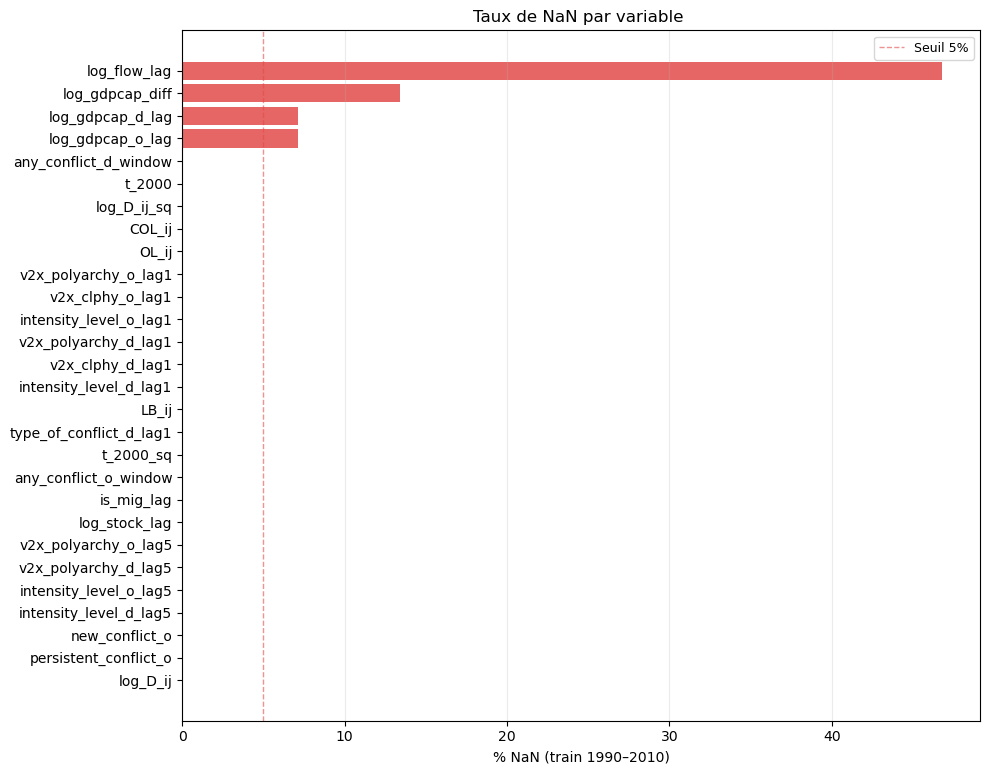

Variables > 5% NaN :
log_gdpcap_o_lag     7.1
log_gdpcap_d_lag     7.1
log_gdpcap_diff     13.4
log_flow_lag        46.8


In [20]:
# taux de NaN par variable clé
vars_audit = list(dict.fromkeys(HURDLE_VARS + X_VOL_COLS + [
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag', 'log_gdpcap_diff',
    'is_mig_lag', 'log_flow_lag', 'log_stock_lag', 'LB_ij',
    'v2x_polyarchy_o_lag5', 'v2x_polyarchy_d_lag5',
    'intensity_level_o_lag5', 'intensity_level_d_lag5',
    'new_conflict_o', 'persistent_conflict_o',
    'any_conflict_o_window', 'any_conflict_d_window',
]))

nan_rates  = {col: df_train[col].isna().mean() * 100 for col in vars_audit if col in df_train.columns}
nan_series = pd.Series(nan_rates).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(nan_series) * 0.28)))
colors = ['#E24B4A' if v > 5 else '#378ADD' for v in nan_series.values]
ax.barh(nan_series.index, nan_series.values, color=colors, alpha=0.85)
ax.axvline(5, color='#E24B4A', lw=1, ls='--', alpha=0.6, label='Seuil 5%')
ax.set_xlabel("% NaN (train 1990–2010)")
ax.set_title("Taux de NaN par variable ")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='x')
plt.tight_layout()
plt.savefig("audit_nan_rates.pdf", bbox_inches='tight')
plt.show()

problemes = nan_series[nan_series > 5]
if problemes.empty:
    print("Aucune variable clé > 5% NaN.")
else:
    print("Variables > 5% NaN :")
    print(problemes.round(1).to_string())

In [21]:
# taux de rétention par dropna successifs
HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration']
VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag']

N_ref  = len(df_train)
step1  = df_train.dropna(subset=['is_mig_lag'])
step2  = step1.dropna(subset=[c for c in HURDLE_REQUIRED if c in step1.columns])
step3b = step2[step2['flow'] > 0]
step3  = step3b.dropna(subset=[c for c in VOLUME_REQUIRED if c in step3b.columns])

print(f"Référence train               : {N_ref:>8,}")
print(f"Après dropna(is_mig_lag)      : {len(step1):>8,}  (-{N_ref-len(step1):,})")
print(f"Après dropna(HURDLE_REQUIRED) : {len(step2):>8,}  (-{len(step1)-len(step2):,})")
print(f"Après dropna(VOLUME_REQUIRED) : {len(step3):>8,}  (-{len(step3b)-len(step3):,} parmi flow>0)")

pertes = {col: step1[col].isna().sum() for col in HURDLE_REQUIRED if col in step1.columns and step1[col].isna().sum() > 0}
if pertes:
    print("\nVariables responsables des pertes Hurdle :")
    for col, n in sorted(pertes.items(), key=lambda x: -x[1]):
        print(f"  {col:<35} {n:,} NaN")
else:
    print("\nAucune perte sur HURDLE_REQUIRED.")

Référence train               :  180,312
Après dropna(is_mig_lag)      :  180,312  (-0)
Après dropna(HURDLE_REQUIRED) :  180,312  (-0)
Après dropna(VOLUME_REQUIRED) :   89,786  (-0 parmi flow>0)

Aucune perte sur HURDLE_REQUIRED.


In [22]:
# pays exclus du train Hurdle et cause racine
pays_ref    = set(df_train['orig'].unique()) | set(df_train['dest'].unique())
pays_hurdle = set(step2['orig'].unique()) | set(step2['dest'].unique())
pays_excl   = sorted(pays_ref - pays_hurdle)

print(f"Pays exclus du train Hurdle : {len(pays_excl)}")
print(f"{'Pays':<8} {'Variable principale manquante':<35} {'Périodes NaN'}")
print("-" * 70)
for pays in pays_excl:
    subset = df_train[(df_train['orig'] == pays) | (df_train['dest'] == pays)]
    counts = {col: subset[col].isna().sum() for col in HURDLE_REQUIRED if col in subset.columns}
    if counts and max(counts.values()) > 0:
        worst     = max(counts, key=counts.get)
        years_nan = sorted(subset[subset[worst].isna()]['year'].unique().tolist())
        print(f"{pays:<8} {worst:<35} {years_nan}")
    else:
        print(f"{pays:<8} {'(autre cause)':<35}")

Pays exclus du train Hurdle : 0
Pays     Variable principale manquante       Périodes NaN
----------------------------------------------------------------------


In [23]:
# distribution des flux et surdispersion
flux_pos = df_ref[df_ref['flow'] > 0]['flow']
print(f"N flux > 0   : {len(flux_pos):,}")
print(f"Médiane      : {flux_pos.median():,.0f}")
print(f"Moyenne      : {flux_pos.mean():,.0f}")
print(f"Écart-type   : {flux_pos.std():,.0f}")
print(f"Max          : {flux_pos.max():,.0f}")
print(f"Var/moy      : {flux_pos.var()/flux_pos.mean():,.0f}  (Poisson invalide si >> 1)")

top20 = (
    df_ref[df_ref['flow'] > 0]
    .groupby(['orig', 'dest'])['flow'].max()
    .sort_values(ascending=False).head(20)
    .reset_index()
)
print("\nTop 20 dyades (flux max toutes années) :")
print(top20.to_string(index=False))

N flux > 0   : 108,428
Médiane      : 45
Moyenne      : 4,389
Écart-type   : 38,028
Max          : 3,309,139
Var/moy      : 329,453  (Poisson invalide si >> 1)

Top 20 dyades (flux max toutes années) :
orig dest    flow
 MEX  USA 3309139
 SYR  TUR 2403930
 PAK  AFG 2014589
 VEN  COL 1626478
 USA  MEX 1584601
 IND  ARE 1559458
 KAZ  RUS 1330702
 IND  USA 1301497
 IRN  AFG 1301368
 UKR  RUS 1238805
 IND  PAK 1209111
 BGD  IND 1207867
 SYR  LBN 1106047
 RWA  COD 1037148
 SYR  IRQ  967307
 AFG  PAK  965868
 CHN  USA  927992
 RUS  UKR  912828
 MMR  THA  796482
 VEN  PER  790696


In [24]:
# cohérence des lags autorégressifs
df_chk = df_ref.sort_values(['orig', 'dest', 'year']).copy()
df_chk['lfl_recomp']    = df_chk.groupby(['orig', 'dest'])['log_flow'].shift(1)
df_chk['ismig_recomp']  = df_chk.groupby(['orig', 'dest'])['is_migration'].shift(1)

mask_lfl = df_chk['log_flow_lag'].notna() & df_chk['lfl_recomp'].notna()
err_lfl  = (df_chk.loc[mask_lfl, 'log_flow_lag'] - df_chk.loc[mask_lfl, 'lfl_recomp']).abs()
print(f"Incohérences log_flow_lag vs recomputed  : {(err_lfl > 1e-4).sum()}")

mask_im = df_chk['is_mig_lag'].notna() & df_chk['ismig_recomp'].notna()
err_im  = (df_chk.loc[mask_im, 'is_mig_lag'] != df_chk.loc[mask_im, 'ismig_recomp']).sum()
print(f"Incohérences is_mig_lag vs recomputed    : {err_im}")

# patch t=1990 : is_mig_lag doit être 0 partout
df_1990 = df_ref[df_ref['year'] == 1990]
n_nan_1990 = df_1990['is_mig_lag'].isna().sum()
print(f"NaN résiduels is_mig_lag à t=1990        : {n_nan_1990}")

Incohérences log_flow_lag vs recomputed  : 0
Incohérences is_mig_lag vs recomputed    : 0
NaN résiduels is_mig_lag à t=1990        : 0


In [25]:
# bornes V-DEM [0, 1]
print("V-DEM [0, 1] :")
for col in VDEM_COLS:
    if col not in df.columns:
        print(f"  {col:<35} ABSENTE")
        continue
    vmin, vmax = df[col].min(), df[col].max()
    flag = "  !" if vmin < 0 or vmax > 1 else ""
    print(f"  {col:<35} [{vmin:.3f}, {vmax:.3f}]{flag}")

print("\nUCDP intensity_level {0, 1, 2} :")
for col in UCDP_INTENSITY:
    if col not in df.columns:
        print(f"  {col:<35} ABSENTE"); continue
    vals = sorted(df[col].dropna().unique().tolist())
    flag = "  !" if any(v not in [0, 1, 2] for v in vals) else ""
    print(f"  {col:<35} {vals}{flag}")

print("\nUCDP type_of_conflict {0, 1, 2, 3, 4} :")
for col in UCDP_TYPE:
    if col not in df.columns:
        print(f"  {col:<35} ABSENTE"); continue
    vals = sorted(df[col].dropna().unique().tolist())
    flag = "  !" if any(v not in [0, 1, 2, 3, 4] for v in vals) else ""
    print(f"  {col:<35} {vals}{flag}")

V-DEM [0, 1] :
  v2x_polyarchy_o_lag1                [0.014, 0.921]
  v2x_polyarchy_d_lag1                [0.014, 0.921]
  v2x_polyarchy_o_lag5                [0.013, 0.921]
  v2x_polyarchy_d_lag5                [0.013, 0.921]
  v2x_clphy_o_lag1                    [0.012, 0.989]
  v2x_clphy_d_lag1                    [0.012, 0.989]
  v2x_clphy_o_lag5                    [0.022, 0.989]
  v2x_clphy_d_lag5                    [0.022, 0.989]

UCDP intensity_level {0, 1, 2} :
  intensity_level_o_lag1              [0.0, 1.0, 2.0]
  intensity_level_d_lag1              [0.0, 1.0, 2.0]
  intensity_level_o_lag5              [0.0, 1.0, 2.0]
  intensity_level_d_lag5              [0.0, 1.0, 2.0]

UCDP type_of_conflict {0, 1, 2, 3, 4} :
  type_of_conflict_o_lag1             [0.0, 2.0, 3.0, 4.0]
  type_of_conflict_d_lag1             [0.0, 2.0, 3.0, 4.0]
  type_of_conflict_o_lag5             [0.0, 2.0, 3.0, 4.0]
  type_of_conflict_d_lag5             [0.0, 2.0, 3.0, 4.0]


In [26]:
# variables binaires
BIN_COLS = ['LB_ij', 'COL_ij', 'OL_ij', 'LL_i', 'LL_j',
            'new_conflict_o', 'new_conflict_d',
            'persistent_conflict_o', 'persistent_conflict_d',
            'any_conflict_o_window', 'any_conflict_d_window',
            'any_intense_o_window', 'any_intense_d_window',
            'any_intl_o_window', 'any_intl_d_window']

print(f"{'Variable':<35} {'Valeurs':<20} {'NaN%'}")
print("-" * 60)
for col in BIN_COLS:
    if col not in df.columns:
        print(f"  {col:<33} ABSENTE"); continue
    vals    = sorted(df[col].dropna().unique().tolist())
    pct_nan = df[col].isna().mean() * 100
    flag    = "  !" if not all(v in [0, 1, 0.0, 1.0] for v in vals) else ""
    print(f"  {col:<33} {str(vals):<20} {pct_nan:.1f}%{flag}")

Variable                            Valeurs              NaN%
------------------------------------------------------------
  LB_ij                             [0, 1]               0.0%
  COL_ij                            [0, 1]               0.0%
  OL_ij                             [0, 1]               0.0%
  LL_i                              [0.0, 1.0]           0.5%
  LL_j                              [0.0, 1.0]           0.5%
  new_conflict_o                    [0, 1]               0.0%
  new_conflict_d                    [0, 1]               0.0%
  persistent_conflict_o             [0, 1]               0.0%
  persistent_conflict_d             [0, 1]               0.0%
  any_conflict_o_window             [0.0, 1.0]           0.0%
  any_conflict_d_window             [0.0, 1.0]           0.0%
  any_intense_o_window              [0.0, 1.0]           0.0%
  any_intense_d_window              [0.0, 1.0]           0.0%
  any_intl_o_window                 [0.0, 1.0]           0.0%
  any_int

In [27]:
# cohérence distance
if 'D_ij' in df.columns:
    print(f"D_ij = 0   : {(df['D_ij'] == 0).sum()}")
    print(f"D_ij NaN   : {df['D_ij'].isna().sum()}")
    recomp   = np.log(df['D_ij'].replace(0, np.nan))
    err_log  = (df['log_D_ij'] - recomp).abs()
    print(f"log_D_ij vs recomputed      : {(err_log > 1e-4).sum()} incohérences")

if 'log_D_ij_sq' in df.columns:
    err_sq = (df['log_D_ij_sq'] - df['log_D_ij']**2).abs()
    print(f"log_D_ij_sq vs log_D_ij^2   : {(err_sq > 1e-4).sum()} incohérences")

if 'logD_times_LB' in df.columns:
    err_int = (df['logD_times_LB'] - df['log_D_ij'] * df['LB_ij']).abs()
    print(f"logD_times_LB vs recomputed : {(err_int > 1e-4).sum()} incohérences")

D_ij = 0   : 0
D_ij NaN   : 0
log_D_ij vs recomputed      : 0 incohérences
log_D_ij_sq vs log_D_ij^2   : 48 incohérences
logD_times_LB vs recomputed : 0 incohérences


In [28]:
# asymétrie gravitaire des flux (sanity check)
DYADES_TEST = [
    ('MEX', 'USA'), ('IND', 'SAU'), ('BGD', 'IND'),
    ('TUR', 'DEU'), ('PHL', 'SAU'), ('CHN', 'USA'),
]
print(f"{'Dyade':<15} {'A→B':>12} {'B→A':>12} {'Ratio':>8}")
print("-" * 50)
for a, b in DYADES_TEST:
    f_ab = df_ref[(df_ref['orig'] == a) & (df_ref['dest'] == b)]['flow'].sum()
    f_ba = df_ref[(df_ref['orig'] == b) & (df_ref['dest'] == a)]['flow'].sum()
    ratio = f_ab / f_ba if f_ba > 0 else np.nan
    print(f"{a}→{b:<10} {f_ab:>12,.0f} {f_ba:>12,.0f} {ratio:>8.1f}x")

Dyade                    A→B          B→A    Ratio
--------------------------------------------------


MEX→USA          14,954,267    7,143,246      2.1x
IND→SAU           1,891,227    1,068,328      1.8x
BGD→IND           5,366,526    2,260,296      2.4x
TUR→DEU           2,257,926    1,412,925      1.6x
PHL→SAU             430,129      261,986      1.6x
CHN→USA           3,288,622    1,154,706      2.8x


In [29]:
# couverture log_stock_lag (diaspora UN DESA)
if 'log_stock_lag' in df.columns:
    print(f"log_stock_lag > 0 : {(df_ref['log_stock_lag'] > 0).mean()*100:.1f}%")
    print(f"log_stock_lag NaN : {df_ref['log_stock_lag'].isna().mean()*100:.1f}%")
    print(f"Médiane (dyades actives) : {df_ref[df_ref['log_stock_lag'] > 0]['log_stock_lag'].median():.2f}")
    for yr in YEARS:
        sub = df_ref[df_ref['year'] == yr]
        print(f"  {yr} : {(sub['log_stock_lag'] > 0).mean()*100:.1f}% couverture")

log_stock_lag > 0 : 17.1%
log_stock_lag NaN : 0.0%
Médiane (dyades actives) : 5.97
  1990 : 0.0% couverture
  1995 : 19.7% couverture
  2000 : 20.2% couverture
  2005 : 20.6% couverture
  2010 : 20.8% couverture
  2015 : 21.3% couverture


In [30]:
# tendance GDP (chutes brutales > 0.5 log-points entre deux périodes)
if 'log_gdpcap_o_lag' in df.columns:
    gdp_trend = (
        df.groupby(['orig', 'year'])['log_gdpcap_o_lag']
        .mean().unstack('year')
    )
    alerte = False
    for c1, c2 in zip(YEARS_TRAIN[:-1], YEARS_TRAIN[1:]):
        if c1 in gdp_trend.columns and c2 in gdp_trend.columns:
            chutes = gdp_trend[gdp_trend[c2] < gdp_trend[c1] - 0.5]
            if len(chutes) > 0:
                print(f"  {c1}→{c2} : {len(chutes)} pays avec chute GDP > 0.5 log-points")
                print(f"    {sorted(chutes.index.tolist())}")
                alerte = True
    if not alerte:
        print("GDP trend : aucune chute brutale détectée.")

  1990→1995 : 7 pays avec chute GDP > 0.5 log-points
    ['GIN', 'LAO', 'LBR', 'NIC', 'SUR', 'TZA', 'VNM']
  1995→2000 : 14 pays avec chute GDP > 0.5 log-points
    ['AGO', 'AZE', 'BIH', 'COD', 'ETH', 'GEO', 'IRQ', 'KGZ', 'LBR', 'MDA', 'MNG', 'NER', 'RWA', 'TJK']
  2000→2005 : 3 pays avec chute GDP > 0.5 log-points
    ['GNB', 'NGA', 'SLE']
  2005→2010 : 1 pays avec chute GDP > 0.5 log-points
    ['COD']


In [31]:
# matrice de corrélation géopolitique (colinéarité)
conflict_cols = [
    'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
    'v2x_polyarchy_o_lag1', 'v2x_polyarchy_d_lag1',
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
]
cols_ok = [c for c in conflict_cols if c in df.columns]
corr    = df[cols_ok].corr().round(2)
print(corr.to_string())
for i in range(len(cols_ok)):
    for j in range(i+1, len(cols_ok)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            print(f"  ALERTE colinéarité : {cols_ok[i]} / {cols_ok[j]}  r={r:.2f}")

                         v2x_clphy_o_lag1  intensity_level_o_lag1  v2x_clphy_d_lag1  intensity_level_d_lag1  v2x_polyarchy_o_lag1  v2x_polyarchy_d_lag1  type_of_conflict_o_lag1  type_of_conflict_d_lag1
v2x_clphy_o_lag1                     1.00                   -0.38              0.02                   -0.00                  0.80                  0.03                    -0.38                    -0.00
intensity_level_o_lag1              -0.38                    1.00             -0.00                   -0.00                 -0.21                 -0.00                     0.94                    -0.00
v2x_clphy_d_lag1                     0.02                   -0.00              1.00                   -0.38                  0.03                  0.80                    -0.00                    -0.38
intensity_level_d_lag1              -0.00                   -0.00             -0.38                    1.00                 -0.00                 -0.21                    -0.00                

In [32]:
# pays attendus Run B
print("Pays récupérés (doivent être présents) :")
for pays in ['PSE', 'COD', 'ROU', 'SRB']:
    present = pays in df['orig'].unique()
    n_obs   = (df['orig'] == pays).sum()
    annees  = sorted(df[df['orig'] == pays][['year', 'log_gdpcap_o_lag']].dropna()['year'].unique().tolist())
    print(f"  {pays} : {'OK' if present else 'ABSENT'}  {n_obs} obs  GDP lag non-NaN : {annees}")

print("\nPays exclus (ne doivent pas apparaître) :")
for pays in PAYS_EXCLUS:
    present = pays in df['orig'].unique() or pays in df['dest'].unique()
    print(f"  {pays} : {'PRESENT — ERREUR' if present else 'absent OK'}")

Pays récupérés (doivent être présents) :
  PSE : OK  1138 obs  GDP lag non-NaN : [2000, 2005, 2010, 2015]
  COD : OK  1138 obs  GDP lag non-NaN : [1990, 1995, 2000, 2005, 2010, 2015]
  ROU : OK  1138 obs  GDP lag non-NaN : [1995, 2000, 2005, 2010, 2015]
  SRB : OK  382 obs  GDP lag non-NaN : [2010, 2015]

Pays exclus (ne doivent pas apparaître) :
  VIR : absent OK
  CLI : absent OK
  GUM : absent OK
  TLS : absent OK
  MYT : absent OK
  CUW : absent OK
  MNE : absent OK
  SSD : absent OK


In [33]:
# récapitulatif go / no-go
BOUNDS = {
    **{c: (0.0, 1.0)  for c in VDEM_COLS},
    **{c: (0.0, 2.0)  for c in UCDP_INTENSITY},
    **{c: (0.0, 4.0)  for c in UCDP_TYPE},
    'log_D_ij'         : (0.0, 12.0),
    'log_D_ij_sq'      : (0.0, 145.0),
    'log_gdpcap_o_lag' : (0.0, 12.0),
    'log_gdpcap_d_lag' : (0.0, 12.0),
    'log_gdpcap_diff'  : (-10.0, 10.0),
    'log_stock_lag'    : (0.0, 20.0),
    'is_mig_lag'       : (0.0, 1.0),
}

SKIP = {'orig', 'dest', 'year', 'dyad', 'flow', 'is_migration', 'log_flow', 'transitivity_proxy'}

print(f"{'Variable':<35} {'NaN%':>6}  {'Min':>8}  {'Max':>8}  Statut")
print("-" * 75)

all_ok = True
for col in ALL_MODEL_VARS:
    if col not in df.columns or col in SKIP:
        continue
    pct_nan   = df[col].isna().mean() * 100
    vmin, vmax = df[col].min(), df[col].max()
    nan_ok    = pct_nan <= 5
    bounds_ok = True
    if col in BOUNDS:
        lo, hi    = BOUNDS[col]
        bounds_ok = (vmin >= lo - 1e-3) and (vmax <= hi + 1e-3)
    ok     = nan_ok and bounds_ok
    statut = "OK" if ok else "PROBLEME"
    if not ok:
        all_ok = False
    print(f"  {col:<33} {pct_nan:>5.1f}%  {vmin:>8.3f}  {vmax:>8.3f}  {statut}")

print()
if all_ok:
    print("Dataset validé — prêt pour la production.")
else:
    print("Des problèmes ont été détectés — voir les lignes PROBLEME ci-dessus.")

Variable                              NaN%       Min       Max  Statut
---------------------------------------------------------------------------
  log_D_ij                            0.0%     2.349     9.899  OK
  log_D_ij_sq                         0.0%     5.519    97.984  OK
  COL_ij                              0.0%     0.000     1.000  OK
  OL_ij                               0.0%     0.000     1.000  OK
  v2x_polyarchy_o_lag1                0.0%     0.014     0.921  OK
  v2x_clphy_o_lag1                    0.0%     0.012     0.989  OK
  intensity_level_o_lag1              0.0%     0.000     2.000  OK
  v2x_polyarchy_d_lag1                0.0%     0.014     0.921  OK
  v2x_clphy_d_lag1                    0.0%     0.012     0.989  OK
  intensity_level_d_lag1              0.0%     0.000     2.000  OK
  LB_ij                               0.0%     0.000     1.000  OK
  t_2000                              0.0%   -10.000    15.000  OK
  t_2000_sq                           0.0%     0.

# audit supplémentaire

In [3]:
for col in ['LL_i', 'LA_i', 'urban_it']:
    pays_nan = df[df[col].isna()]['orig'].unique()
    print(f"{col} : {sorted(pays_nan)}")

LL_i : ['PSE']
LA_i : ['PSE']
urban_it : ['ESH', 'GLP', 'GUF', 'MTQ', 'REU']


In [4]:
for col in ['log_gdpcap_o_lag', 'log_gdpcap_d_lag']:
    pays_nan = df[df[col].isna()]['orig'].unique()
    print(f"{col} : {sorted(pays_nan)}")

log_gdpcap_o_lag : ['ABW', 'AFG', 'ARM', 'AZE', 'BIH', 'BLR', 'CZE', 'ERI', 'ESH', 'EST', 'GEO', 'GLP', 'GUF', 'HRV', 'KAZ', 'KGZ', 'LBN', 'LTU', 'LVA', 'MDA', 'MKD', 'MOZ', 'MTQ', 'POL', 'PRK', 'PSE', 'REU', 'ROU', 'RUS', 'SVK', 'SVN', 'TJK', 'TKM', 'UKR', 'UZB', 'YEM']
log_gdpcap_d_lag : ['ABW', 'AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESH', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FRA', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GLP', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GTM', 'GUF', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', '

In [5]:
import pandas as pd
df = pd.read_csv("../data/panel_june_ready.csv")

pays_nan_o = ['ABW', 'AFG', 'ARM', 'AZE', 'BIH', 'BLR', 'CZE', 'ERI', 'ESH', 'EST',
              'GEO', 'GLP', 'GUF', 'HRV', 'KAZ', 'KGZ', 'LBN', 'LTU', 'LVA', 'MDA',
              'MKD', 'MOZ', 'MTQ', 'POL', 'PRK', 'PSE', 'REU', 'ROU', 'RUS', 'SVK',
              'SVN', 'TJK', 'TKM', 'UKR', 'UZB', 'YEM']

print(f"{'Pays':<8} {'Années avec NaN GDP lag'}")
print("-" * 50)
for pays in pays_nan_o:
    sub    = df[(df['orig'] == pays) & df['log_gdpcap_o_lag'].isna()]
    annees = sorted(sub['year'].unique().tolist())
    n_total = (df['orig'] == pays).sum()
    n_nan   = len(sub)
    print(f"{pays:<8} {annees}  ({n_nan}/{n_total} obs)")

Pays     Années avec NaN GDP lag
--------------------------------------------------
ABW      [1990]  (189/1138 obs)
AFG      [1990, 1995, 2000]  (567/1138 obs)
ARM      [1990]  (189/1138 obs)
AZE      [1990]  (189/1138 obs)
BIH      [1990]  (189/1138 obs)
BLR      [1990]  (189/1138 obs)
CZE      [1990]  (189/1138 obs)
ERI      [1990, 1995]  (378/1138 obs)
ESH      [1990, 1995, 2000, 2005, 2010, 2015]  (1138/1138 obs)
EST      [1990, 1995]  (378/1138 obs)
GEO      [1990]  (189/1138 obs)
GLP      [1990, 1995, 2000, 2005, 2010, 2015]  (1138/1138 obs)
GUF      [1990, 1995, 2000, 2005, 2010, 2015]  (1138/1138 obs)
HRV      [1990]  (189/1138 obs)
KAZ      [1990]  (189/1138 obs)
KGZ      [1990]  (189/1138 obs)
LBN      [1990]  (189/1138 obs)
LTU      [1990, 1995]  (378/1138 obs)
LVA      [1990, 1995]  (378/1138 obs)
MDA      [1990]  (189/1138 obs)
MKD      [1990]  (189/1138 obs)
MOZ      [1990, 1995]  (378/1138 obs)
MTQ      [1990, 1995, 2000, 2005, 2010, 2015]  (1138/1138 obs)
POL      [1990